In [1]:
import copy
import os
import pathlib
import time
from typing import Mapping
import itertools
import functools

In [2]:
import numpy as np
from scipy import stats
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib
from matplotlib import pyplot as plt

In [3]:
from drmdp import dataproc

In [4]:
import warnings

In [5]:
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

In [6]:
warnings.filterwarnings("ignore")

In [7]:
files = tf.io.gfile.glob(
    f"{pathlib.Path.home()}/fs/drmdp/workflows/controljob/agg/1772983724/1772992432/metrics/*.parquet"
)

In [8]:
df_metrics = dataproc.read_data(files, reader="pd")

In [9]:
df_metrics.iloc[0]["meta"]["env_spec"]

{'args': {'constraint_violation_reward': -10.0,
  'emit_state': False,
  'max_episode_steps': 10000,
  'penalty_gamma': 1.0,
  'reward_fn': 'pos-enf'},
 'feats_spec': array([{'args': {'tiling_dim': 3.0}, 'name': 'tile-observation-action-ft'}],
       dtype=object),
 'name': 'Finite-CC-ShuntDc-v0'}

In [10]:
df_metrics

,episode,exp_id,meta,returns,steps,metrics,method
0,390,1772983724-0067d357-Finite-CC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[11425.588676040405, 11855.309485639467, 11906...","[10000, 10000, 854, 10000, 10000, 5985, 6795, ...","{'returns': {'mean': 11501.326835673426, 'std'...",FR
3,390,1772983724-0519c138-Finite-CC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[11738.834433644248, 10928.992765198936, 11132...","[6572, 4215, 3379, 7948, 10000, 6324, 3098, 10...","{'returns': {'mean': 10026.432969495087, 'std'...",BLADE-TD
4,390,1772983724-0561605a-Finite-SC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[1050.724894112128, 820.7110265811008, 939.221...","[328, 1526, 455, 636, 361, 1179, 246, 266, 185...","{'returns': {'mean': 1021.7995423610597, 'std'...",IMR
7,390,1772983724-0c1a6486-Finite-TC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[6786.188323206214, 7923.673874855165, 7579.95...","[5039, 3761, 53, 7662, 10000, 138, 10000, 1314...","{'returns': {'mean': 7116.390955422966, 'std':...",IMR
8,390,1772983724-0ee19c07-Finite-SC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[224.84979924568395, 1343.1712552824158, 277.9...","[3491, 243, 36, 8, 11, 1541, 1554, 7, 41, 7, 2...","{'returns': {'mean': 578.71541393419, 'std': 5...",DMR
...,...,...,...,...,...,...,...
245,210,1772983724-f768ece2-Finite-CC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[129.2177113574301, 141.91227011151037, 175.87...","[101, 77, 36, 117, 28, 31, 11, 29, 77, 24, 237...","{'returns': {'mean': 146.78908431076604, 'std'...",OP-A
248,210,1772983724-fa9e2560-Finite-TC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[2393.457856081534, 2075.1664275337844, 2451.7...","[9, 102, 8, 14, 8, 108, 6579, 7, 7, 2964, 1761...","{'returns': {'mean': 1463.7337672035012, 'std'...",DMR
249,210,1772983724-fcaef02e-Finite-TC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[7978.698568076154, 8269.575630667052, 7661.57...","[8582, 197, 6783, 3370, 10000, 3020, 1954, 334...","{'returns': {'mean': 7074.941044575697, 'std':...",IMR
250,210,1772983724-fe0e2030-Finite-SC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[1178.4924371012733, 1210.7621488027414, 1170....","[222, 590, 664, 638, 548, 4592, 388, 1108, 108...","{'returns': {'mean': 1335.9234477657872, 'std'...",BLADE-TD


In [11]:
envs = dataproc.get_distinct_envs(df_metrics)

In [12]:
for env_name, spec in sorted(envs.items()):
    print(env_name, spec)

Finite-CC-PermExDc-v0 {'constraint_violation_reward': -10.0, 'emit_state': False, 'max_episode_steps': 10000, 'penalty_gamma': 1.0, 'reward_fn': 'pos-enf'}
Finite-CC-ShuntDc-v0 {'constraint_violation_reward': -10.0, 'emit_state': False, 'max_episode_steps': 10000, 'penalty_gamma': 1.0, 'reward_fn': 'pos-enf'}
Finite-SC-PermExDc-v0 {'constraint_violation_reward': -10.0, 'emit_state': False, 'max_episode_steps': 10000, 'penalty_gamma': 1.0, 'reward_fn': 'pos-enf'}
Finite-SC-ShuntDc-v0 {'constraint_violation_reward': -10.0, 'emit_state': True, 'max_episode_steps': 10000, 'penalty_gamma': 1.0, 'reward_fn': 'pos-enf'}
Finite-TC-PermExDc-v0 {'constraint_violation_reward': -10.0, 'emit_state': False, 'max_episode_steps': 10000, 'penalty_gamma': 1.0, 'reward_fn': 'pos-enf'}
Finite-TC-ShuntDc-v0 {'constraint_violation_reward': -10.0, 'emit_state': True, 'max_episode_steps': 10000, 'penalty_gamma': 1.0, 'reward_fn': 'pos-enf'}


In [13]:
def parse_delay_config(df_input: pd.DataFrame):
    df = copy.deepcopy(df_input)

    def parse_mu(delay_config):
        if delay_config is None:
            return None
        args = delay_config["args"]
        try:
            return args["delay"]
        except KeyError:
            return args["lam"]
        except KeyError as exc:
            raise ValueError(f"Unknown delay config {args}") from exc

    df["delay_type"] = df["delay_config"].apply(lambda dc: dc["name"] if dc else None)
    df["delay_mu"] = df["delay_config"].apply(parse_mu)
    del df["delay_config"]
    return df

## Return Curvers

In [14]:
def parse_specs(xs, scope: str, col: str):
    if isinstance(xs, Mapping):
        return xs[col]
    values = tuple(el[col] for el in xs)
    if scope == "feats":
        if col == "name":
            return dataproc.FEAT_PROCS[values[0]]
        return values[0]
    return values

In [15]:
def create_returns_plotting_data(
    df_data: pd.DataFrame,
):
    df_result = copy.deepcopy(df_data)
    for key in (
        "delay_config",
        "gamma",
    ):
        df_result[key] = df_result["meta"].apply(lambda meta: meta["problem_spec"][key])

    specs = {
        "env": df_result["meta"].apply(lambda meta: meta["env_spec"]),
        "feats": df_result["meta"].apply(lambda meta: meta["env_spec"]["feats_spec"]),
    }

    for prefix, col_fam in specs.items():
        for col in ("name", "args"):
            df_result[f"{prefix}_{col}"] = col_fam.apply(
                functools.partial(parse_specs, scope=prefix, col=col)
            )

    del df_result["meta"]
    del df_result["steps"]
    del df_result["metrics"]

    df_result = parse_delay_config(df_result)
    df_baseline = df_result[pd.isnull(df_result["delay_type"])]
    df_result = df_result[~pd.isnull(df_result["delay_type"])]
    baseline_dfs = []
    distinct_algo_configs = df_result[["delay_type", "delay_mu"]].drop_duplicates()

    # Replicate baseline results for each config
    # to make plotting easier.
    for row in distinct_algo_configs.to_dict("records"):
        print(row)
        df_baseline_rp = copy.deepcopy(df_baseline)
        # reward period is one
        df_baseline_rp["delay_type"] = row["delay_type"]
        df_baseline_rp["delay_mu"] = row["delay_mu"]
        baseline_dfs.append(df_baseline_rp)
    df_result = pd.concat(baseline_dfs + [df_result], axis=0)
    df_result = df_result.sort_values(["method", "delay_type", "delay_mu"])

    # agg returns
    return {"sarsa": df_result}

In [16]:
df_returns_curves = create_returns_plotting_data(df_metrics)

{'delay_type': 'clipped-poisson', 'delay_mu': 2.0}
{'delay_type': 'clipped-poisson', 'delay_mu': 4.0}
{'delay_type': 'clipped-poisson', 'delay_mu': 8.0}
{'delay_type': 'clipped-poisson', 'delay_mu': 6.0}


In [17]:
df_returns_curves["sarsa"]

,episode,exp_id,returns,method,gamma,env_name,env_args,feats_name,feats_args,delay_type,delay_mu
3,390,1772983724-0519c138-Finite-CC-PermExDc-v0,"[11738.834433644248, 10928.992765198936, 11132...",BLADE-TD,0.99,Finite-CC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",spliced-tiles,{'tiling_dim': 4.0},clipped-poisson,2.0
14,390,1772983724-1496a20c-Finite-TC-PermExDc-v0,"[10574.45283662062, 9069.696104626932, 11283.3...",BLADE-TD,1.00,Finite-TC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},clipped-poisson,2.0
41,390,1772983724-28513a41-Finite-SC-PermExDc-v0,"[852.2068807378664, 1292.422449408716, 738.335...",BLADE-TD,1.00,Finite-SC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",spliced-tiles,{'tiling_dim': 3.0},clipped-poisson,2.0
72,390,1772983724-512171c8-Finite-CC-ShuntDc-v0,"[12625.654914085231, 12793.355524512826, 12657...",BLADE-TD,1.00,Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},clipped-poisson,2.0
74,390,1772983724-52384a3d-Finite-CC-ShuntDc-v0,"[11023.146624640294, 10879.640397000725, 11147...",BLADE-TD,0.99,Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},clipped-poisson,2.0
...,...,...,...,...,...,...,...,...,...,...,...
181,210,1772983724-b8af8853-Finite-CC-PermExDc-v0,"[151.957974392609, 149.29588873437572, 132.186...",OP-A,1.00,Finite-CC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",spliced-tiles,{'tiling_dim': 4.0},clipped-poisson,4.0
190,210,1772983724-bd5ba3cd-Finite-SC-PermExDc-v0,"[381.0217890380996, 248.63287886319154, 170.00...",OP-A,1.00,Finite-SC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",spliced-tiles,{'tiling_dim': 3.0},clipped-poisson,4.0
206,210,1772983724-d004ae09-Finite-SC-ShuntDc-v0,"[188.61183848044922, 169.9093647631264, 188.20...",OP-A,1.00,Finite-SC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,clipped-poisson,4.0
222,210,1772983724-e21f422d-Finite-TC-ShuntDc-v0,"[199.75917076232324, 229.5242391117224, 171.83...",OP-A,0.99,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,clipped-poisson,4.0


In [18]:
sorted(df_returns_curves["sarsa"]["method"].unique())

['BLADE-TD', 'BLADE-TD[N-B]', 'DMR', 'FR', 'IMR', 'OP-A']

In [19]:
def export_figure(
    figure, name: str, format: str = "pdf", dpi=300, transparent: bool = True
):
    # to be able to save, we must plot
    base_dir = os.path.dirname(name)
    if not os.path.exists(base_dir):
        tf.io.gfile.makedirs(base_dir)
    figure.savefig(f"{name}.{format}", dpi=dpi, format=format, transparent=transparent)

In [20]:
MARKERS = ["s", "p", "o", "P", "X", "d"]

In [21]:
DASHES = {
    "FR": (1, 0),
    "DMR": (1, 1),
    "IMR": (1, 2),
    "L-TDD": (2, 1),
    "BLADE-TD": (2, 2),
    "OP-A": (6, 2),
    "OP-S": (6, 3),
}

In [22]:
METHODS_PALETTES = {
    key: palette for key, palette in zip(dataproc.ORDERED_METHODS, sns.color_palette())
}

In [23]:
sorted(df_returns_curves["sarsa"]["env_name"].unique())

['Finite-CC-PermExDc-v0',
 'Finite-CC-ShuntDc-v0',
 'Finite-SC-PermExDc-v0',
 'Finite-SC-ShuntDc-v0',
 'Finite-TC-PermExDc-v0',
 'Finite-TC-ShuntDc-v0']

In [24]:
SHORT_NAMES = {
    "Finite-CC-PermExDc-v0": "CC-PermExDc",
    "Finite-CC-ShuntDc-v0": "CC-ShuntDc",
    "Finite-SC-PermExDc-v0": "SC-PermExDc",
    "Finite-SC-ShuntDc-v0": "SC-ShuntDc",
    "Finite-TC-PermExDc-v0": "TC-PermExDc",
    "Finite-TC-ShuntDc-v0": "TC-ShuntDc-v0",
    "GridWorld-v0": "GW",
    "IceWorld-v0": "IW",
    "MountainCar-v0": "MC",
    "RedGreen-v0": "RGS",
}

In [25]:
def get_legend_order(desired_ordered_items, current_order):
    included_items = [
        item for item in desired_ordered_items if item in set(current_order)
    ]
    item_to_index = {item: idx for idx, item in enumerate(current_order)}
    return [item_to_index[item] for item in included_items]

In [26]:
get_legend_order(dataproc.ORDERED_METHODS, sorted(["DMR", "BLADE-TD[N-B]"]))

[0, 1]

In [27]:
def plot_eval_result(
    env: str,
    gamma: float,
    df_data: pd.DataFrame,
    suffix: str,
    max_episode: int = np.inf,
    max_reward_period: int = 8,
    output_dir: str = "figures/returnplots",
    ylog_scale: bool = True,
    linestyles=DASHES,
    palette=METHODS_PALETTES,
    ordered_methods=dataproc.ORDERED_METHODS,
    exclude_methods=set(["BLADE-TD[N-B]"]),
):
    start = time.time()
    df_data = df_data[suffix]
    filter_mask = (
        (df_data["env_name"] == env)
        & (df_data["gamma"] == gamma)
        & (df_data["episode"] <= max_episode)
        & (df_data["delay_mu"] <= max_reward_period)
        & (df_data["method"].apply(lambda met: met not in exclude_methods))
    )
    df_result = copy.deepcopy(df_data[filter_mask])

    def rename_env(env: str):
        try:
            return SHORT_NAMES[env]
        except KeyError:
            return env

    df_result["name"] = df_result["env_name"].apply(rename_env)
    del df_result["exp_id"]
    del df_result["env_args"]
    del df_result["env_name"]
    del df_result["feats_args"]
    del df_result["delay_type"]

    # Legend sorts items alphabetically,
    # but we have a preference
    methods = sorted(df_result["method"].unique())
    legend_order = get_legend_order(ordered_methods, methods)

    # limit episodes if too many
    # to avoid OOM
    if df_result["episode"].max() > 1_000 - 10:
        mask = df_result["episode"].apply(lambda episode: episode % 100 == 0)
        df_result = df_result[mask]

    df_result = df_result.explode("returns")

    # split to give flexibility in plotting
    name_prefix = "_".join([str(token) for token in ["rc", env, gamma]])
    end = time.time()
    print(f"Proc: {end - start}s. Plotting...")

    start = time.time()
    # Build one by one

    specs = sorted(df_result["feats_name"].unique())
    delays = sorted(df_result["delay_mu"].unique())
    nrows, ncols = len(specs), len(delays)
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=(3 * ncols, 3 * nrows), sharey=True
    )

    title_template = ", ".join(
        [f"{rename_env(env)}", "P = {col_name}\nEnc = {row_name}"]
    )
    axes = axes.flatten()
    for idx, ((spec, delay), ax) in enumerate(
        zip(itertools.product(specs, delays), axes)
    ):
        df_slice = df_result[
            (df_result["feats_name"] == spec) & (df_result["delay_mu"] == delay)
        ]

        sns.lineplot(
            data=df_slice,
            x="episode",
            y="returns",
            hue="method",
            style="method",
            palette=palette,
            dashes=linestyles,
            style_order=None,
            estimator="mean",
            errorbar=("ci", 95),
            n_boot=1000,
            legend="auto",
            ax=ax,
        )
        if ylog_scale:
            ax.set_yscale("log")

        ax.set_xlabel("Episode")
        ax.set_ylabel("Log(Average Returns)" if ylog_scale else "Average Returns")
        ax.set_title(
            ", ".join([f"{rename_env(env)}", f"$\lambda$ = {delay} \nEnc = {spec}"])
        )

    # Drop all but the last legend
    handles, labels = None, None
    for idx, ax in enumerate(axes):
        if idx < len(axes) - 1:
            # Save from the first plot
            if handles is None:
                handles, labels = ax.get_legend_handles_labels()
            # Drop legend
            ax.get_legend().remove()
        else:
            # Remove legend title
            ax.legend(title=None)
            # Re-order legend
            ax.legend(
                [handles[idx] for idx in legend_order],
                [labels[idx] for idx in legend_order],
            )
    plt.tight_layout()
    plt.show()

    export_figure(fig, os.path.join(output_dir, f"{name_prefix}_{suffix}"))
    end = time.time()
    print(f"Plotted: {end - start}s.")

Proc: 0.009090185165405273s. Plotting...


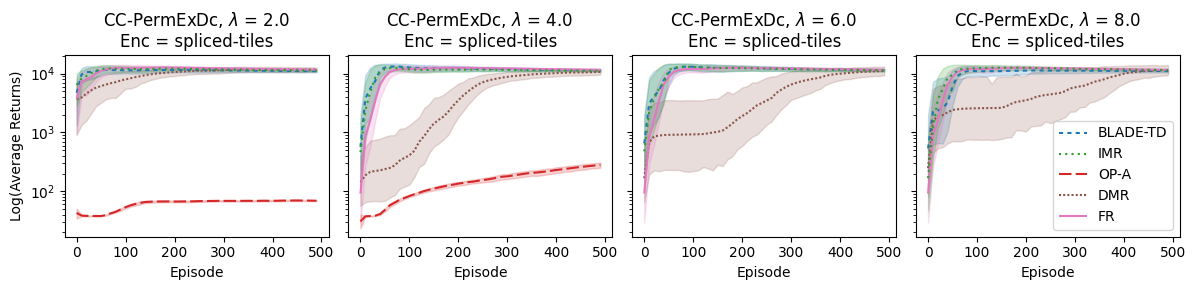

Plotted: 6.160240888595581s.


In [28]:
plot_eval_result(
    env="Finite-CC-PermExDc-v0",
    gamma=1.0,
    df_data=df_returns_curves,
    suffix="sarsa",
)

Proc: 0.007069826126098633s. Plotting...


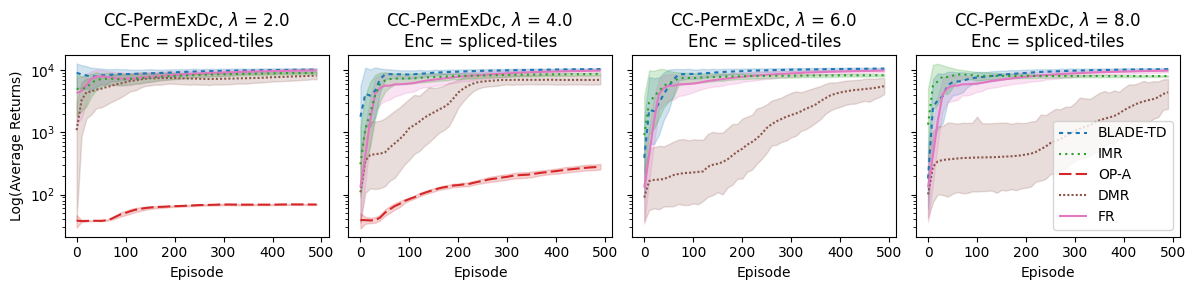

Plotted: 6.019886016845703s.


In [29]:
plot_eval_result(
    env="Finite-CC-PermExDc-v0", gamma=0.99, df_data=df_returns_curves, suffix="sarsa"
)

Proc: 0.007058858871459961s. Plotting...


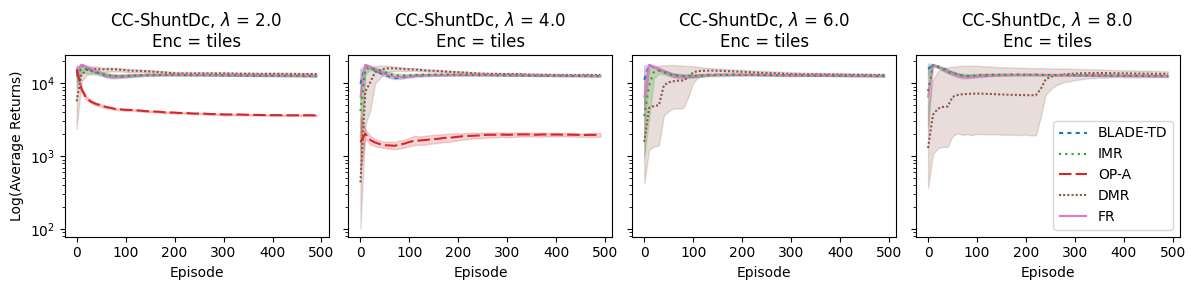

Plotted: 5.8854660987854s.


In [30]:
plot_eval_result(
    env="Finite-CC-ShuntDc-v0", gamma=1.0, df_data=df_returns_curves, suffix="sarsa"
)

Proc: 0.006757974624633789s. Plotting...


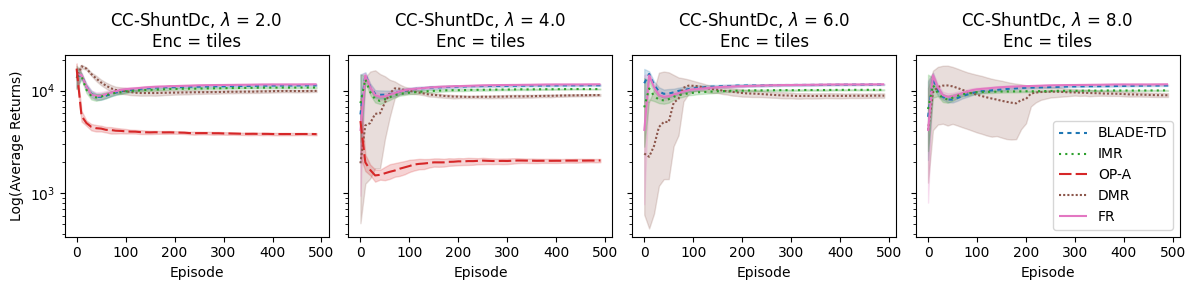

Plotted: 5.898216962814331s.


In [31]:
plot_eval_result(
    env="Finite-CC-ShuntDc-v0", gamma=0.99, df_data=df_returns_curves, suffix="sarsa"
)

Proc: 0.007449150085449219s. Plotting...


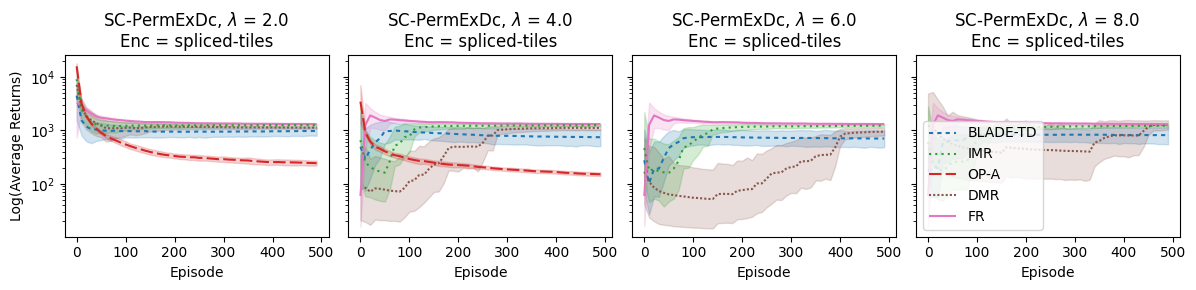

Plotted: 6.050899028778076s.


In [32]:
plot_eval_result(
    env="Finite-SC-PermExDc-v0", gamma=1.0, df_data=df_returns_curves, suffix="sarsa"
)

Proc: 0.007503032684326172s. Plotting...


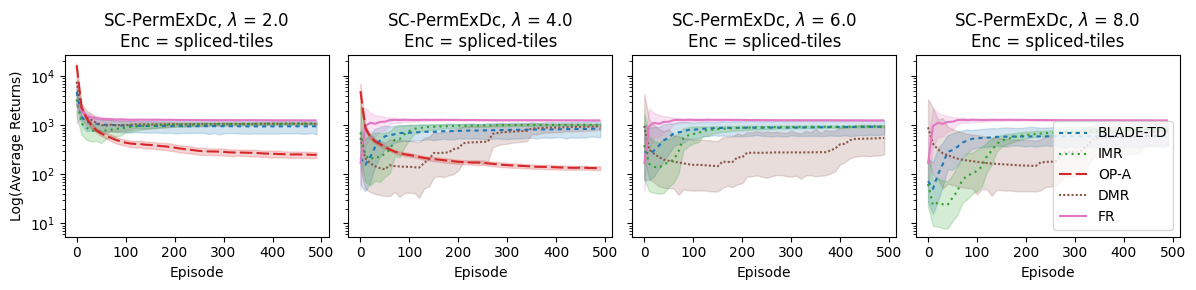

Plotted: 5.956859827041626s.


In [33]:
plot_eval_result(
    env="Finite-SC-PermExDc-v0", gamma=0.99, df_data=df_returns_curves, suffix="sarsa"
)

Proc: 0.0072290897369384766s. Plotting...


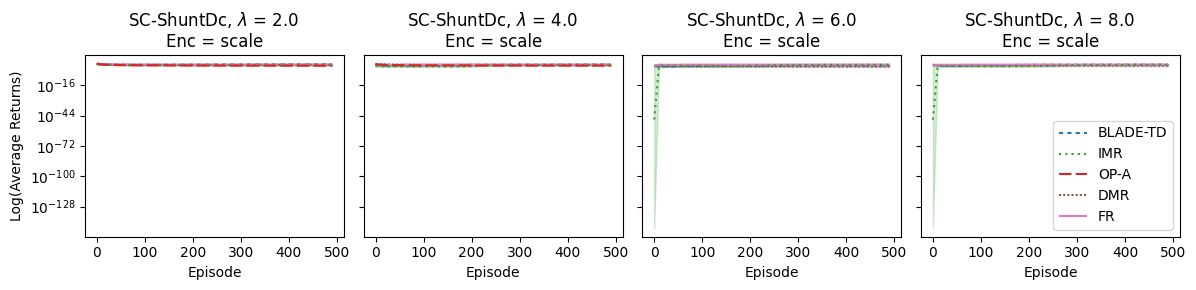

Plotted: 5.7667319774627686s.


In [34]:
plot_eval_result(
    env="Finite-SC-ShuntDc-v0", gamma=1.0, df_data=df_returns_curves, suffix="sarsa"
)

Proc: 0.00687098503112793s. Plotting...


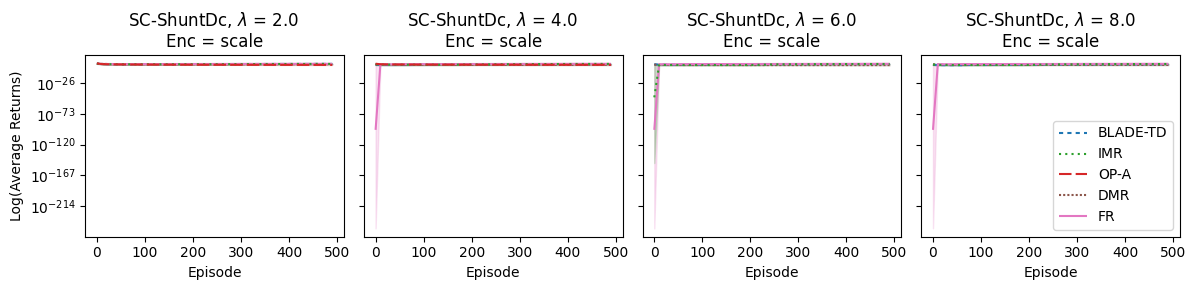

Plotted: 5.930468797683716s.


In [35]:
plot_eval_result(
    env="Finite-SC-ShuntDc-v0", gamma=0.99, df_data=df_returns_curves, suffix="sarsa"
)

Proc: 0.0073680877685546875s. Plotting...


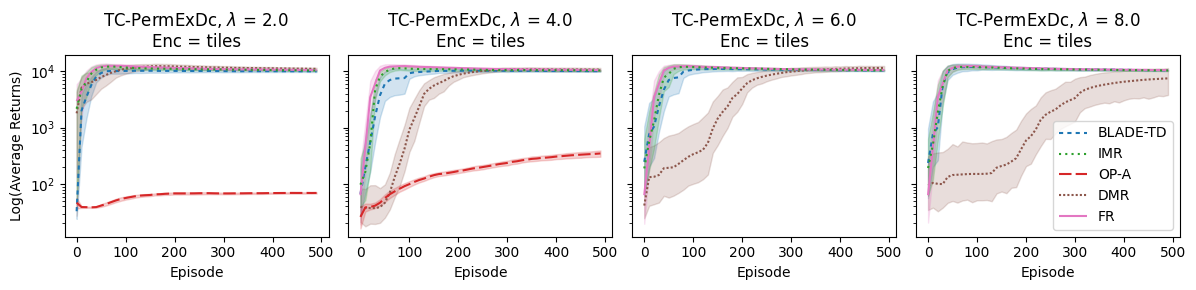

Plotted: 5.913178205490112s.


In [36]:
plot_eval_result(
    env="Finite-TC-PermExDc-v0", gamma=1.0, df_data=df_returns_curves, suffix="sarsa"
)

Proc: 0.007511138916015625s. Plotting...


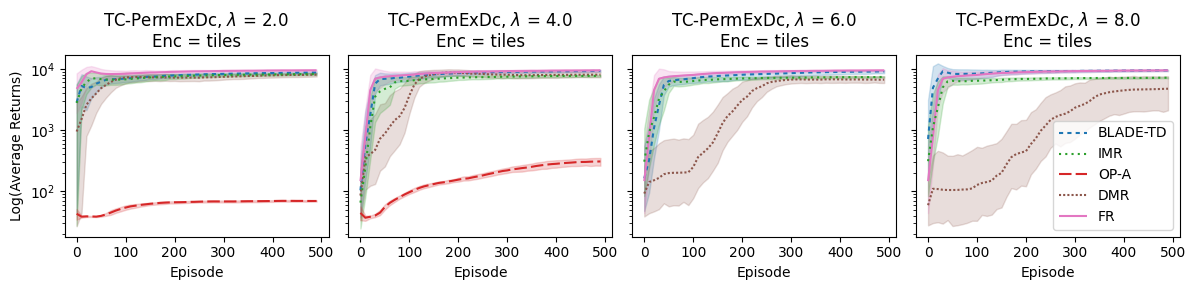

Plotted: 5.93486213684082s.


In [37]:
plot_eval_result(
    env="Finite-TC-PermExDc-v0", gamma=0.99, df_data=df_returns_curves, suffix="sarsa"
)

Proc: 0.006793975830078125s. Plotting...


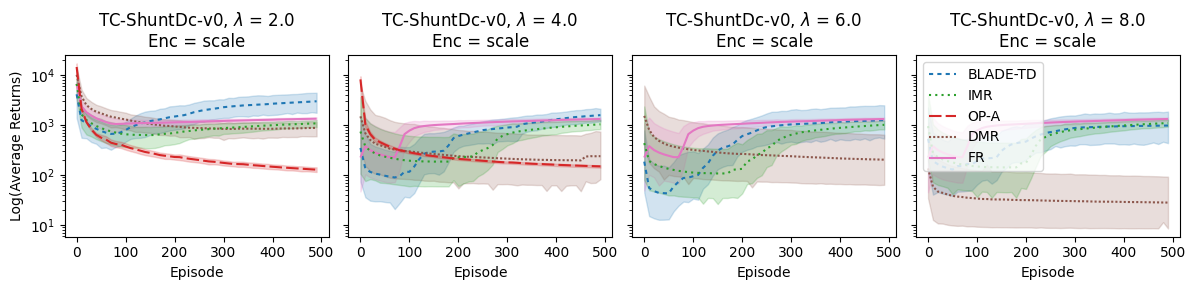

Plotted: 6.168000936508179s.


In [38]:
plot_eval_result(
    env="Finite-TC-ShuntDc-v0", gamma=1.0, df_data=df_returns_curves, suffix="sarsa"
)

Proc: 0.006862163543701172s. Plotting...


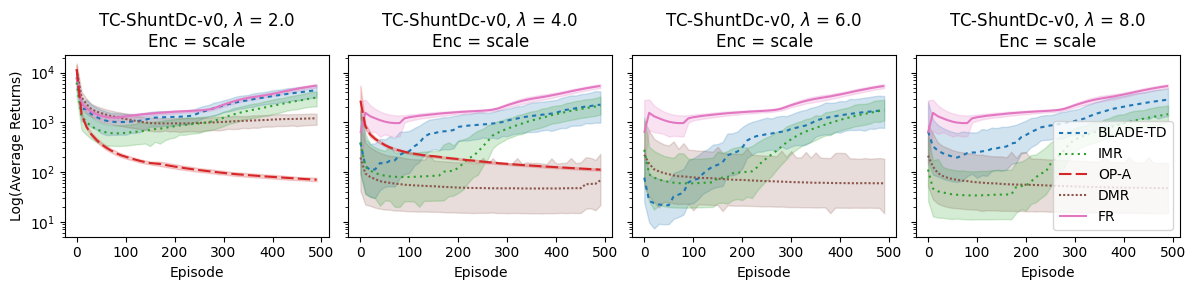

Plotted: 5.9709460735321045s.


In [39]:
plot_eval_result(
    env="Finite-TC-ShuntDc-v0", gamma=0.99, df_data=df_returns_curves, suffix="sarsa"
)